In [1]:
# Data Visualization — Book Dataset

## Project Objective

# The goal of this project is to transform book data into meaningful visualizations, identify patterns, compare categories, and communicate insights clearly.

## Dataset

# The dataset contains 1,000 books with information about their titles, prices, ratings, availability, categories, and product URLs.

## Questions to Explore

# 1. Which book categories appear most frequently?
# 2. How are book ratings distributed?
# 3. What does the price distribution look like?
# 4. Which categories have higher average prices?
# 5. Is there a relationship between book ratings and prices?
# 6. What important insights can we communicate through a visual dashboard?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("../data/books_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (1000, 6)


,title,price,rating,availability,category,url
0,A Light in the Attic,51.77,Three,In stock,Poetry,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,One,In stock,Historical Fiction,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,One,In stock,Fiction,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,Four,In stock,Mystery,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,History,https://books.toscrape.com/catalogue/sapiens-a...


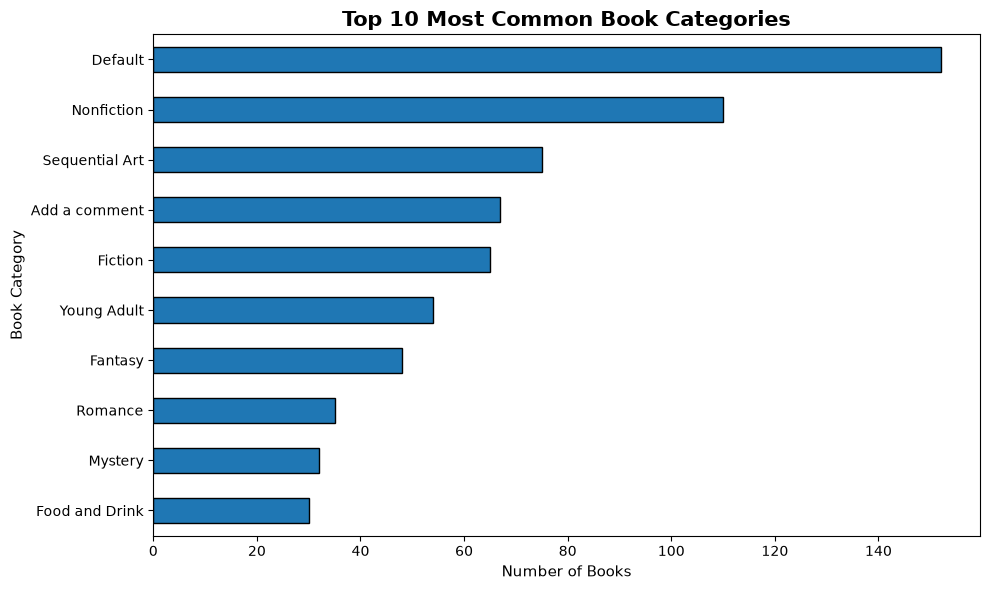

In [ ]:
# Count books in each category and select the top 10
# Which categories have the most books in our dataset?
top_categories = df["category"].value_counts().head(10)

# Create the chart
plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title(
    "Top 10 Most Common Book Categories",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Books", fontsize=11)
plt.ylabel("Book Category", fontsize=11)

plt.tight_layout()

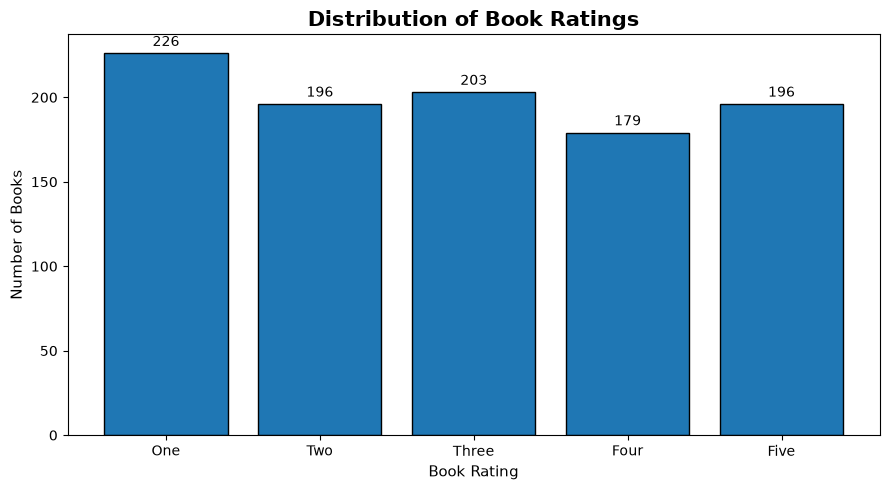

In [9]:
# Count books for each rating
# Which ratings are most common, and are high ratings more common than low ratings?

rating_order = ["One", "Two", "Three", "Four", "Five"]

rating_counts = (
    df["rating"]
    .value_counts()
    .reindex(rating_order, fill_value=0)
)

# Create the chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    rating_order,
    rating_counts.values,
    edgecolor="black"
)

plt.title(
    "Distribution of Book Ratings",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Book Rating", fontsize=11)
plt.ylabel("Number of Books", fontsize=11)

# Display the count above each bar
plt.bar_label(bars, padding=3)

plt.tight_layout()

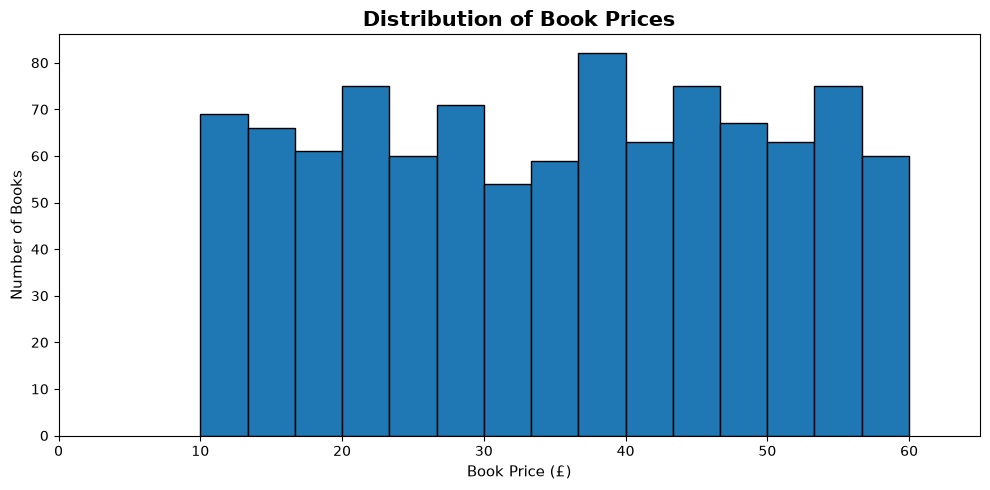

In [8]:
# What price range is most common among the books, and how are prices spread across the dataset?

plt.figure(figsize=(10, 5))

plt.hist(
    df["price"],
    bins=15,
    edgecolor="black"
)

plt.title(
    "Distribution of Book Prices",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Book Price (£)", fontsize=11)
plt.ylabel("Number of Books", fontsize=11)

plt.xlim(0, 65)
plt.tight_layout()

<Figure size 1000x600 with 0 Axes>

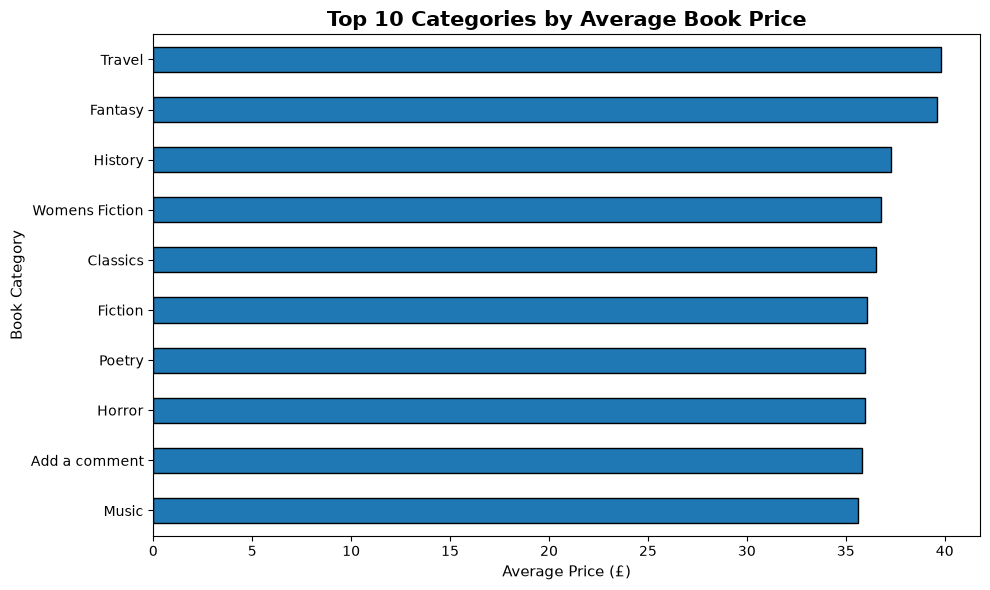

In [10]:
# Calculate book count and average price for each category
category_summary = df.groupby("category").agg(
    book_count=("title", "count"),
    average_price=("price", "mean")
)

# Keep categories with at least 10 books
category_summary = category_summary[
    category_summary["book_count"] >= 10
]

# Select the 10 categories with the highest average prices
top_avg_prices = category_summary.nlargest(
    10, "average_price"
)

# Create the chart
plt.figure(figsize=(10, 6))

bars = top_avg_prices.sort_values("average_price").plot(
    kind="barh",
    y="average_price",
    legend=False,
    edgecolor="black",
    figsize=(10, 6)
)

plt.title(
    "Top 10 Categories by Average Book Price",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Average Price (£)", fontsize=11)
plt.ylabel("Book Category", fontsize=11)

plt.tight_layout()

In [11]:
# Do books with higher ratings tend to have higher prices?
# Convert text ratings into numeric values
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating_numeric"] = df["rating"].map(rating_map)

print("Rating conversion completed!")
print(df[["rating", "rating_numeric"]].head())

Rating conversion completed!
  rating  rating_numeric
0  Three               3
1    One               1
2    One               1
3   Four               4
4   Five               5


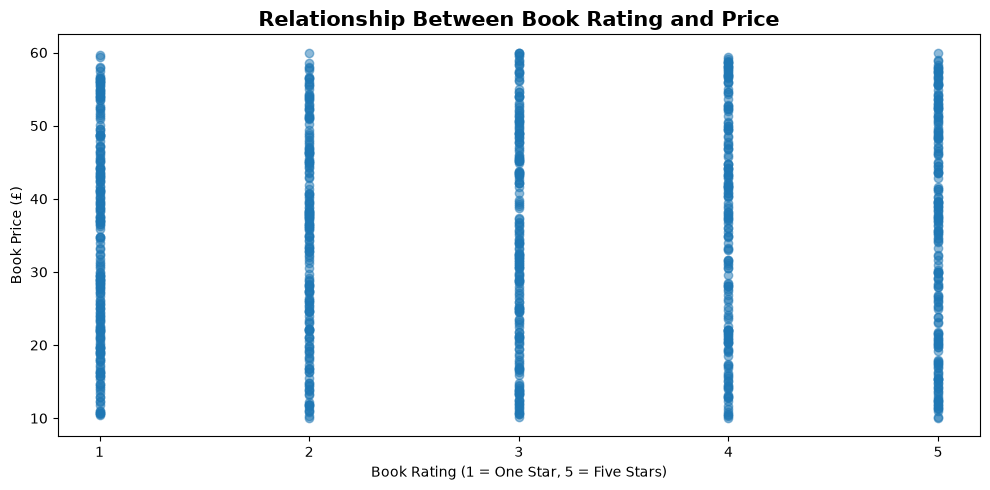

In [12]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["rating_numeric"],
    df["price"],
    alpha=0.5
)

plt.title(
    "Relationship Between Book Rating and Price",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Book Rating (1 = One Star, 5 = Five Stars)")
plt.ylabel("Book Price (£)")

plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()


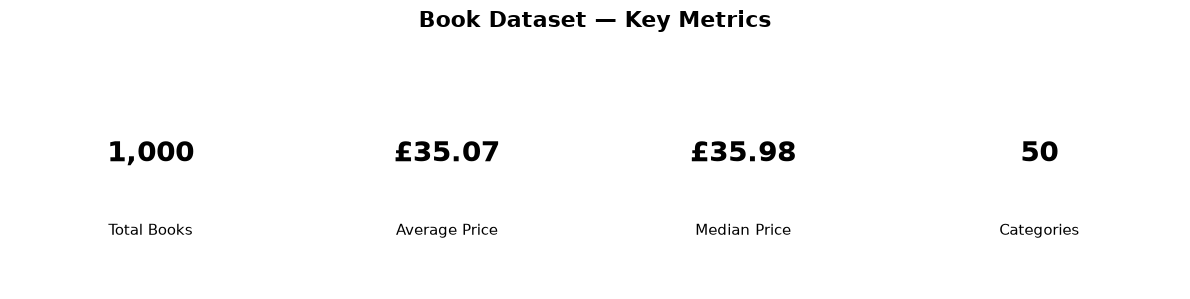

In [13]:
# Calculate key metrics
total_books = len(df)
average_price = df["price"].mean()
median_price = df["price"].median()
total_categories = df["category"].nunique()

# Create a dashboard-style KPI summary
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

kpis = [
    ("Total Books", f"{total_books:,}"),
    ("Average Price", f"£{average_price:.2f}"),
    ("Median Price", f"£{median_price:.2f}"),
    ("Categories", f"{total_categories}")
]

for ax, (label, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.58, value,
        ha="center", va="center",
        fontsize=20, fontweight="bold"
    )
    ax.text(
        0.5, 0.25, label,
        ha="center", va="center",
        fontsize=11
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

fig.suptitle(
    "Book Dataset — Key Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Data Story — Insights from the Book Dataset

### 1. Dataset Overview

The dataset contains 1,000 books across 50 categories. The average book price is approximately £35.07, and the median price is £35.98.

### 2. Category Patterns

The category distribution shows which subjects appear most frequently in the dataset. The average-price comparison helps identify categories that are relatively expensive among categories with at least 10 books.

### 3. Rating Patterns

The rating distribution shows how books are distributed across the five rating levels. Comparing these ratings with book prices helps investigate whether higher ratings are associated with higher prices.

### 4. Price and Rating Relationship

The scatter plot and previous statistical analysis show that rating and price have almost no relationship in this dataset. The Spearman correlation is approximately 0.0292, so a higher rating does not reliably indicate a higher price.

### 5. Data Limitations

All books are marked as in stock, which limits availability comparisons. Also, 67 records (6.7%) have the suspicious category value "Add a comment". This should be investigated before using the data for further analysis.

### Conclusion

The visualizations summarize book categories, rating patterns, price distribution, and the relationship between ratings and prices. They show how charts can help communicate patterns clearly while highlighting data limitations that should be considered before making decisions.
